In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, LeakyReLU, Dropout, Flatten, Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import plot_model  # Para diagrama de modelo

In [2]:
# 1. Cargar datos reales Fashion-MNIST (28x28 grises, 10 clases: T-shirt, Trouser, etc.)
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()
print(f"Entrenamiento: {train_X.shape}, Prueba: {test_X.shape}")  # (60000,28,28), (10000,28,28)[page:20]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28), Prueba: (10000, 28, 28)


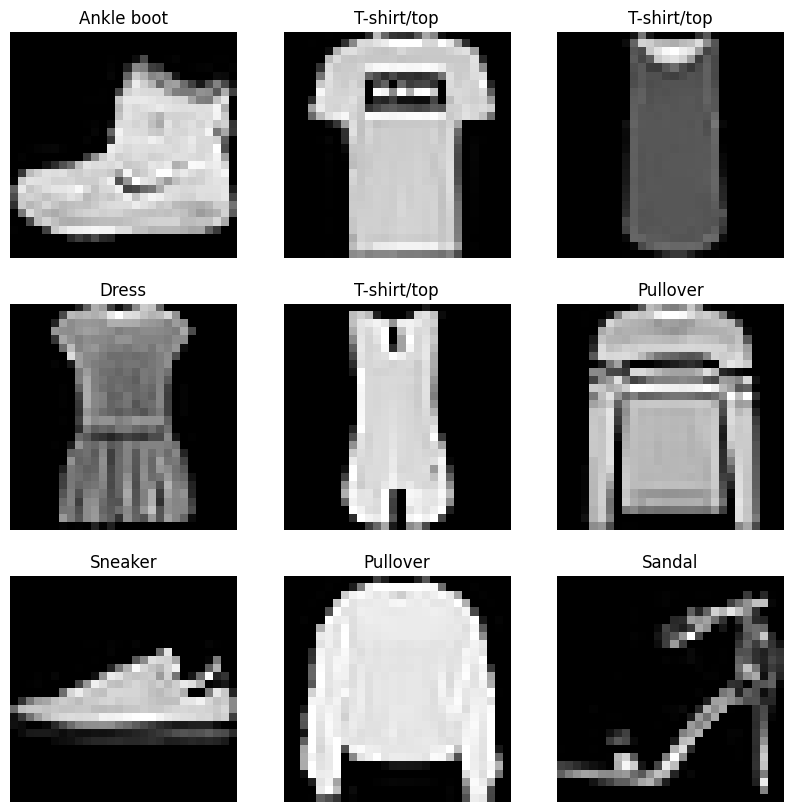

In [5]:
# Visualizar primeras 9 imágenes con etiquetas
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10,10))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(train_X[i], cmap='gray')
  plt.title(class_names[train_Y[i]])
  plt.axis('off')
plt.show()


In [6]:
# 2. Preprocesamiento: reshape, normalizar (0-1), one-hot encoding, split validación
train_X = train_X.reshape(-1, 28, 28, 1).astype('float32') / 255.
test_X = test_X.reshape(-1, 28, 28, 1).astype('float32') / 255.
train_Y = to_categorical(train_Y, 10)
test_Y = to_categorical(test_Y, 10)
train_X, valid_X, train_Y, valid_Y = train_test_split(train_X, train_Y, test_size=0.2, random_state=13)

In [7]:
# 3. Construir CNN: 3 Conv2D + MaxPool + Dropout + Dense
model = Sequential([
    Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), padding='same'),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same'),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), padding='same'),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same'),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), padding='same'),
    Dropout(0.4),

    Flatten(),
    Dense(128),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()  # ~356k parámetros[page:20]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 4. Entrenar (20 épocas, batch 64)
history = model.fit(train_X, train_Y, batch_size=64, epochs=20, validation_data=(valid_X, valid_Y), verbose=1)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 122ms/step - accuracy: 0.7773 - loss: 0.5986 - val_accuracy: 0.8637 - val_loss: 0.3803
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 138s 116ms/step - accuracy: 0.8636 - loss: 0.3752 - val_accuracy: 0.8856 - val_loss: 0.3076
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 87s 116ms/step - accuracy: 0.8781 - loss: 0.3267 - val_accuracy: 0.8980 - val_loss: 0.2735
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 114ms/step - accuracy: 0.8900 - loss: 0.2985 - val_accuracy: 0.8963 - val_loss: 0.2823
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 87s 115ms/step - accuracy: 0.8971 - loss: 0.2814 - val_accuracy: 0.9058 - val_loss: 0.2494
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 115ms/step - accuracy: 0.9003 - loss: 0.2682 - val_accuracy: 0.9097 - val_loss: 0.2425
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 113ms/step - accuracy: 0.9060 - loss: 0.2555 - val_accuracy: 0.9128 - val_loss: 0.2361
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 115ms/step - accuracy: 0.9076 - loss:

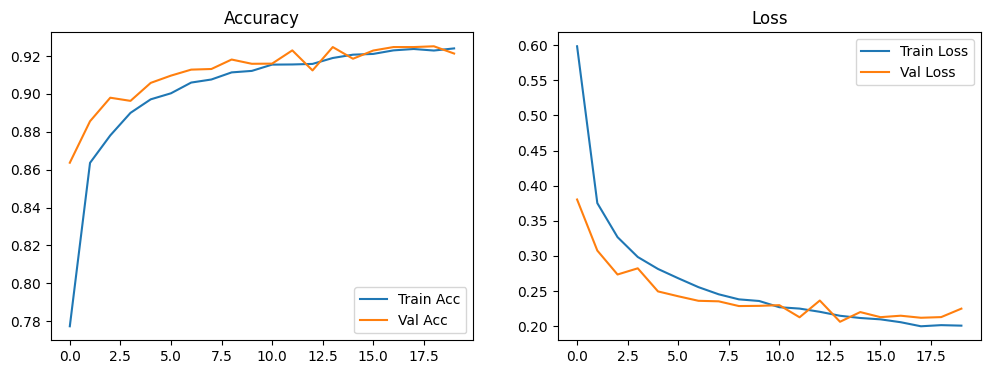

In [9]:
# 5. Gráficos explicativos: curvas de loss/accuracy
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()  # Muestra convergencia ~92% acc, sin sobreajuste fuerte gracias a dropout[page:20]

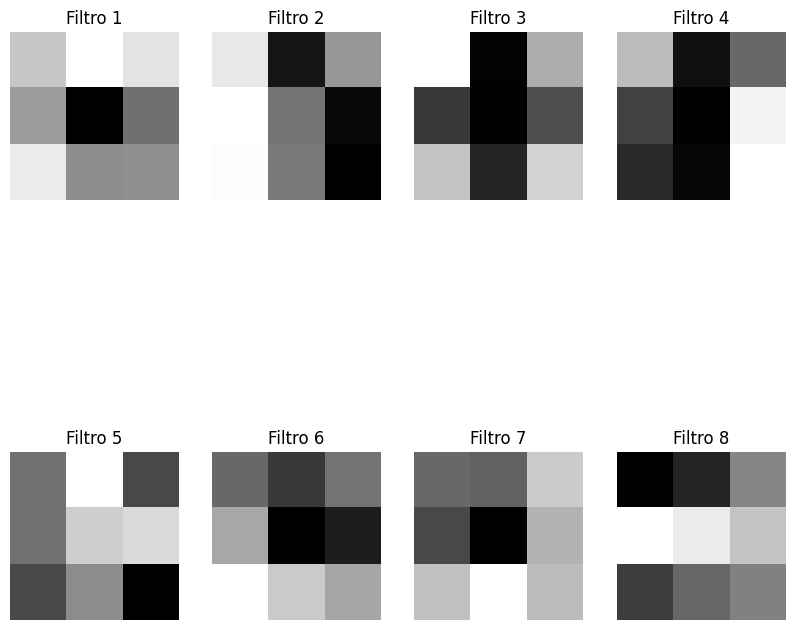

In [10]:
# 6. Visualizar filtros de 1ra capa (qué patrones aprende)
filters = model.layers[0].get_weights()[0][:,:,0,:8]  # Primeros 8 filtros (28x28x1 -> 32)
plt.figure(figsize=(10,10))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(filters[:,:,i], cmap='gray')
    plt.title(f'Filtro {i+1}')
    plt.axis('off')
plt.show()  # Bordes, esquinas, texturas[page:20]

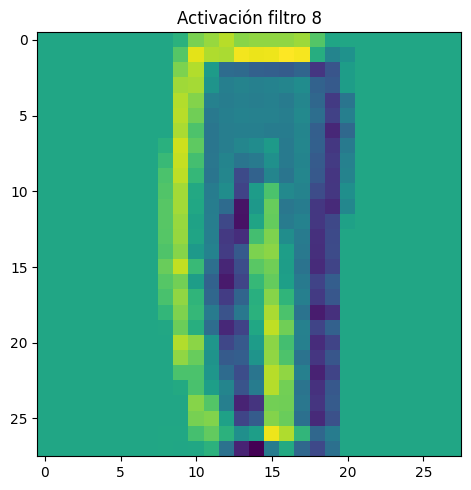

In [16]:
# 7. Activaciones: cómo responde 1ra conv a una imagen
img = train_X[0:1]  # Primera imagen
conv_output = model.layers[0](img)  # Solo 1ra conv
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(np.squeeze(img), cmap='gray')
plt.title('Imagen original')
for i in range(8):
  #plt.subplot(2,4,i+2)
  plt.imshow(np.squeeze(conv_output[0,:,:,i]), cmap='viridis')
  plt.title(f'Activación filtro {i+1}')
plt.tight_layout()
plt.show()  # Resalta bordes/texturas relevantes[page:20]


Accuracy prueba: 91.74%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


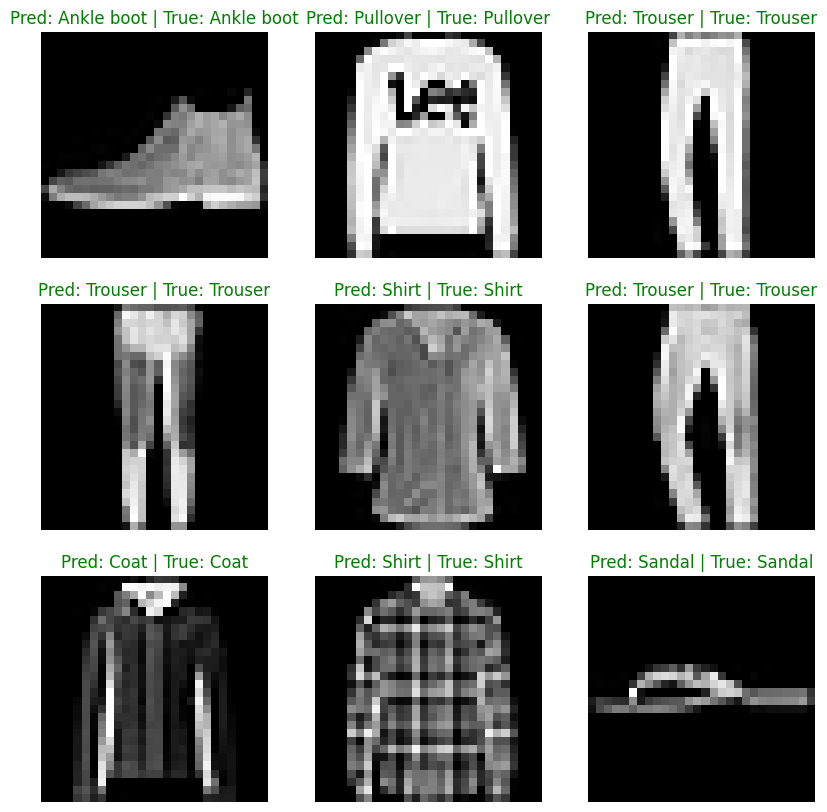

In [14]:
# 8. Evaluación y predicciones
test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)
print(f'Accuracy prueba: {test_acc:.2%}')  # ~92%[page:20]

# Predicciones en 9 muestras de test
preds = model.predict(test_X[:9])
pred_classes = np.argmax(preds, axis=1)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(np.squeeze(test_X[i]), cmap='gray')
    color = 'g' if pred_classes[i] == np.argmax(test_Y[i]) else 'r'
    plt.title(f'Pred: {class_names[pred_classes[i]]} | True: {class_names[np.argmax(test_Y[i])]}', color=color)
    plt.axis('off')
plt.show()